In [1]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated,Sequence
from langchain_core.messages import BaseMessage

In [2]:
load_dotenv()

True

In [3]:
from langchain_groq import ChatGroq
model = ChatGroq(
    api_key=os.getenv('GROQ_API_KEY'),
    model = "openai/gpt-oss-120b"
)

e:\Langgraph\myvenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [246]:
class Agent_State(TypedDict):

    input : str
    ai_output : str
    decision : str

In [247]:
def ai_node(state: Agent_State):
    text = state['input']

    response = model.invoke(text)

    return {'ai_output': [response]}


def human_node(state: Agent_State):
    
    print("\n AI OUTPUT")
    text = state['ai_output']

    decision = input('\n Approve? (Yes/No): ')

    return {'decision': decision}

In [ ]:
def check_dicision(state: Agent_State):
    if state['decision'] == 'Yes':
        return 
    elif state['decision'] == "NO":
        return [
            
        ]

In [249]:
graph = StateGraph(Agent_State)
graph.add_node('ai', ai_node)
graph.add_node('human', human_node)

In [ ]:
graph.add_edge(START,'ai')
graph.add_edge('ai', 'human')

graph.add_conditional_edges(
    'human',
    check_dicision,
    {
        'dicision': END
        'end': END
    }
)

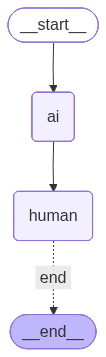

In [251]:
app=graph.compile()
app

In [ ]:
app.invoke({
    "input": "Write a LinkedIn post on AI"
})





 AI OUTPUT


KeyError: None